# LOCAL BOUNDED VALIDATION COPY

Drive and install cells are replaced. Evaluation uses deliberately near-cap fixtures, not complete-game strength tests. Notebook 02 skips training. Temporary paths in outputs are not the production Colab paths.

# No RL 01 - Classical Baseline

Use the existing alpha-beta engine without a neural model. Evaluation coefficients can be tuned through games in notebook 03. Default path: **01 -> 03 -> 04 -> 05**. Optional supervised path: **01 -> 02 -> 03 -> 04 -> 05**. Use a CPU runtime here.

## Mount Google Drive

In [1]:
print("Local validation only: no Drive mount.")

Local validation only: no Drive mount.


## Project Setup

Uses `configs/no_rl.yaml`. No league, self-play, PPO, or DQN is run. Colab's installed PyTorch is preserved.

In [2]:
from pathlib import Path
import sys, subprocess
from IPython.display import display
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
def show_figure(fig):
    display(fig)
    plt.close(fig)
PROJECT_ROOT = Path('/mnt/d/Benjamin Data/Introduction to AI/Chess Agent Competition/colab_chess_research/results/no_rl_notebook_validation/fixture-pp15y2lv')
sys.path.insert(0, str(PROJECT_ROOT))
from chess_rl.non_rl import load_no_rl_config
from chess_rl.reproducibility import read_json, sha256
cfg = load_no_rl_config(PROJECT_ROOT)
cfg["non_rl"]["variant"] = "classical"
cfg["run_id"] = "no_rl_local_fixture"
cfg["evaluation"].update(development_games=2, heldout_games=2, bootstrap_samples=100)
cfg["non_rl"]["tuning"].update(trials=1, games_per_trial=2, confirmation_games=2)
print("LOCAL FIXTURE: CPU, one ply before game cap, two games per opponent.")
print("No Drive mount, no training, no export/compliance execution.")
from chess_rl import plots
original_plot_matches = plots.plot_matches
def fixture_plot(root, run_id, summaries, name):
    fig = original_plot_matches(root, run_id, summaries, name)
    fig.axes[0].set_title('LOCAL FIXTURE ONLY: one ply before the game cap')
    fig.axes[0].set_xlabel('Score (%); intervals unavailable with one opening pair')
    plots.save(fig, root, run_id, name)
    return fig
plots.plot_matches = fixture_plot


LOCAL FIXTURE: CPU, one ply before game cap, two games per opponent.
No Drive mount, no training, no export/compliance execution.


## Choose the Variant

For no neural training, leave `non_rl.variant: classical` in `configs/no_rl.yaml`. For supervised learning without RL, set it to `supervised` and change `run_id` to a new name such as `no_rl_supervised_v1`. Keep the same configuration throughout one run. Do not change the original `default.yaml` to select this workflow.

In [3]:
print("Settings file:", PROJECT_ROOT / "configs/no_rl.yaml")
print(cfg["search"])

Settings file: /mnt/d/Benjamin Data/Introduction to AI/Chess Agent Competition/colab_chess_research/results/no_rl_notebook_validation/fixture-pp15y2lv/configs/no_rl.yaml
{'max_depth': 6, 'quiescence_depth': 4, 'value_eval_mix': 0.0, 'policy_ordering': False, 'time_budget_fraction': 0.05, 'max_budget_ms': 1000.0, 'transposition_table_size': 100000, 'policy_top_k_root': 'all', 'policy_top_k_internal': 'all', 'evaluation_weights': {'material': 1.0, 'piece_square': 1.0, 'activity': 2.0, 'bishop_pair': 35.0, 'doubled_pawns': -12.0, 'isolated_pawns': -10.0, 'passed_pawns': 20.0, 'passed_pawn_advance': 8.0}}


## What the Baseline Knows

The current evaluator uses material, piece-square tables, attacked-square activity, bishop pairs, doubled/isolated pawns, and passed pawns. Iterative deepening, alpha-beta, quiescence, and a transposition table provide calculation. This notebook does not add opening books or implement every strategy from a chess textbook.

## Inspect a Position

The board is standard chess, not a reduced grid environment. The classical evaluator returns a score from the side-to-move perspective. The displayed position is an illustrative input, not a benchmark.

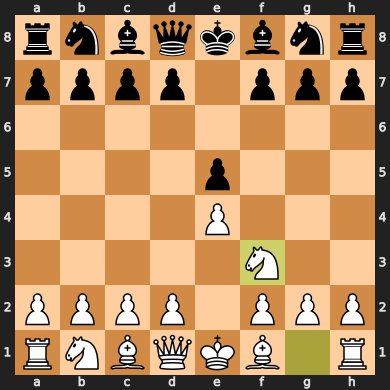

Legal moves: 29
Static evaluation (centipawn units): -58.0
material                     0 x       1 =     0.00 cp
piece_square               -50 x       1 =   -50.00 cp
activity                    -4 x       2 =    -8.00 cp
bishop_pair                  0 x      35 =     0.00 cp
doubled_pawns                0 x     -12 =    -0.00 cp
isolated_pawns               0 x     -10 =    -0.00 cp
passed_pawns                 0 x      20 =     0.00 cp
passed_pawn_advance          0 x       8 =     0.00 cp


In [4]:
import chess
from chess_rl.classical_evaluation import evaluate_cp, evaluation_breakdown
from chess_rl.search import SearchEngine
from chess_rl.non_rl import variant_config

board = chess.Board()
for uci in ("e2e4", "e7e5", "g1f3"):
    board.push_uci(uci)
display(board)
print("Legal moves:", board.legal_moves.count())
print("Static evaluation (centipawn units):", evaluate_cp(board, cfg["search"]["evaluation_weights"]))
for row in evaluation_breakdown(board, cfg["search"]["evaluation_weights"]):
    print(f'{row["feature"]:22s} {row["value"]:7g} x {row["weight"]:7g} = {row["contribution_cp"]:8.2f} cp')

## Search for a Move

This runs the classical search directly. A legal fallback is available before deeper search. The board must be unchanged when search returns. This is ordinary correctness work, not submission validation.

Move: b8c6 | Completed depth: 2 | Nodes: 2377 | Time (ms): 350.03


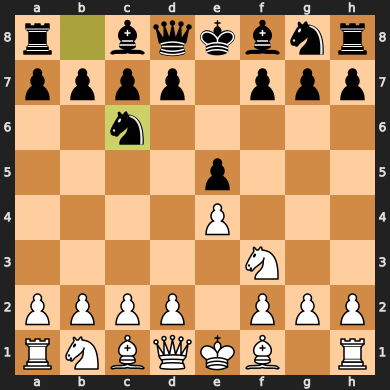

In [5]:
classical_cfg = variant_config(cfg, "classical")
engine = SearchEngine(classical_cfg["search"])
before = board.fen()
result = engine.choose(board, time_left_ms=2000)
assert result.move in board.legal_moves
assert board.fen() == before
assert engine.neural is None
print("Move:", result.move.uci(), "| Completed depth:", result.depth,
      "| Nodes:", result.nodes, "| Time (ms):", round(result.elapsed_ms, 2))
after = board.copy()
after.push(result.move)
display(after)

## Reserve Opening Suites

The same immutable development/held-out fixtures are shared with the research project. Their legal random playout provenance is recorded; they are not balanced or the platform's hidden opening set.

In [6]:
print("Local validation substitutes one-ply-to-cap opening fixtures.")

Local validation substitutes one-ply-to-cap opening fixtures.


## Check Workflow Correctness

Bounded tests verify the independent classical path and its stage dependencies. They do not start full training, full tournaments, or submission checks.

In [7]:
subprocess.check_call([sys.executable, "-m", "pytest", "-q", "tests/test_non_rl.py",
                       "tests/test_evaluation_tuning.py"],
                      cwd=PROJECT_ROOT)

.

.

.

.

.........

...........

.

.                                               [100%]


26 passed in 10.16s


0

## Next Notebook

Classical: open **03_evaluate_no_rl.ipynb**. Supervised: open **02_optional_supervised.ipynb**. Do not run the original RL notebook 03 for this workflow.